# Multiple Linear Regression

1. Load the dataset
2. Basic checks (preview, missing values)
3. Check multicollinearity using correlation matrix
4. Create dummy variables
5. Fit multiple linear regression model
6. Apply backward elimination for model refinement


In [1]:
# =========================================================
# 1) IMPORT LIBRARIES
# =========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm

In [2]:
# =========================================================
# 2) LOAD THE DATASET
# =========================================================

from google.colab import files

print("Upload your file")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)


print("Dataset shape (rows, columns):", df.shape)
df.head()

Upload your file


Saving californiahousing.csv to californiahousing.csv
Dataset shape (rows, columns): (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


In [3]:
# =========================================================
# 3) QUICK DATA CHECKS
# =========================================================
df.info()

print("\nMissing values per column:")
print(df.isna().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB

Missing values per column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
media

In [5]:
# =========================================================
# 4) HANDLE MISSING VALUES (SIMPLE APPROACH)
# =========================================================
# Fill missing numeric values with the column mean.

df = df.copy()

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

print("Missing values after filling numeric columns:")
print(df.isna().sum())


Missing values after filling numeric columns:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


Correlation Matrix:
                    longitude  latitude  housing_median_age  total_rooms  \
longitude            1.000000 -0.924664           -0.108197     0.044568   
latitude            -0.924664  1.000000            0.011173    -0.036100   
housing_median_age  -0.108197  0.011173            1.000000    -0.361262   
total_rooms          0.044568 -0.036100           -0.361262     1.000000   
total_bedrooms       0.069260 -0.066658           -0.318998     0.927253   
population           0.099773 -0.108785           -0.296244     0.857126   
households           0.055310 -0.071035           -0.302916     0.918484   
median_income       -0.015176 -0.079809           -0.119034     0.198050   

                    total_bedrooms  population  households  median_income  
longitude                 0.069260    0.099773    0.055310      -0.015176  
latitude                 -0.066658   -0.108785   -0.071035      -0.079809  
housing_median_age       -0.318998   -0.296244   -0.302916      -0.

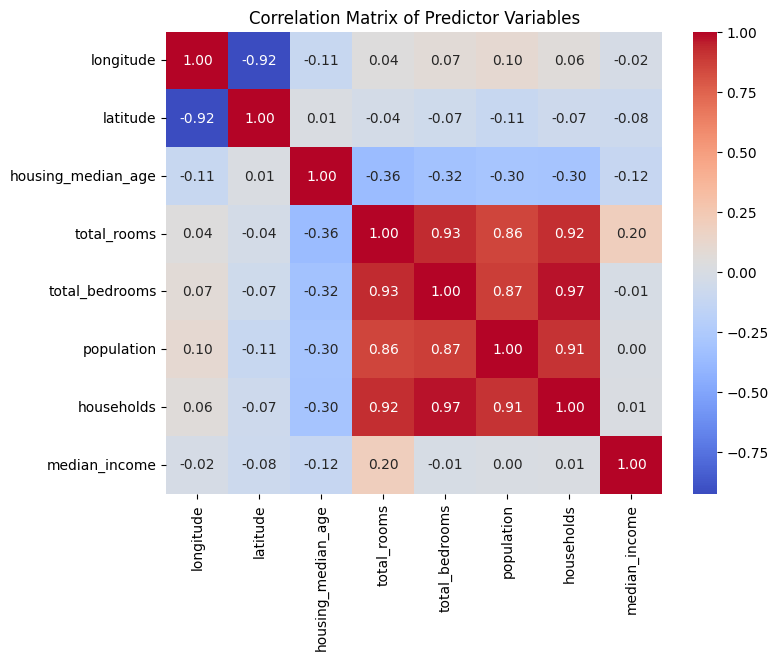


Highly correlated variable pairs (|r| > 0.70):
latitude and longitude: 0.92
total_bedrooms and total_rooms: 0.93
population and total_rooms: 0.86
population and total_bedrooms: 0.87
households and total_rooms: 0.92
households and total_bedrooms: 0.97
households and population: 0.91

variables selected for removal
['total_rooms']


In [10]:
# =========================================================
# 5) CHECK MULTICOLLINEARITY USING CORRELATION MATRIX
# =========================================================

import seaborn as sns

numeric_predictors = df.select_dtypes(include=np.number).drop(columns=["median_house_value"])

corr_matrix = numeric_predictors.corr()

print("Correlation Matrix:")
print(corr_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Predictor Variables")
plt.show()

# Identify highly correlated variables
threshold = 0.70

print("\nHighly correlated variable pairs (|r| > 0.70):")
variables_to_remove = set()

found = False
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        corr_value = abs(corr_matrix.iloc[i,j])
        if corr_value > threshold:
            print(f"{corr_matrix.columns[i]} and {corr_matrix.columns[j]}: {corr_value:.2f}")
            found = True
            var1 = corr_matrix.columns[i]
            var2 = corr_matrix.columns[j]

            # remove total_rooms
            if "total_rooms" in [var1, var2]:
              variables_to_remove.add("total_rooms")

print("\nvariables selected for removal")
print(list(variables_to_remove))

df = df.drop(columns=variables_to_remove)

if not found:
    print("No serious multicollinearity detected.")

# If highly correlated variables are found,
# remove one based on theoretical relevance before regression.



In [11]:
cat_col = "ocean_proximity"
if cat_col in df.columns:
    df_model = pd.get_dummies(df, columns=[cat_col], drop_first=True, dtype=int)
else:
    df_model = df.copy()
    print(f"Note: Column '{cat_col}' not found, so no dummy variables were created.")

print("New shape after dummy variables:", df_model.shape)
df_model.head()

New shape after dummy variables: (20640, 12)


,longitude,latitude,housing_median_age,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41,129.0,322,126,8.3252,452600,0,0,1,0
1,-122.22,37.86,21,1106.0,2401,1138,8.3014,358500,0,0,1,0
2,-122.24,37.85,52,190.0,496,177,7.2574,352100,0,0,1,0
3,-122.25,37.85,52,235.0,558,219,5.6431,341300,0,0,1,0
4,-122.25,37.85,52,280.0,565,259,3.8462,342200,0,0,1,0


In [12]:
# =========================================================
# 7) DEFINE X (PREDICTORS) AND y (TARGET)
# =========================================================
target_col = "median_house_value"
X = df.drop(columns=[target_col])
y = df[target_col]

print("X shape (rows, columns):", X.shape)
print("y shape (rows,):", y.shape)


X shape (rows, columns): (20640, 8)
y shape (rows,): (20640,)


In [13]:
# =========================================================
# 8) SPLIT INTO TRAIN AND TEST SETS
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Train X:", X_train.shape, "Train y:", y_train.shape)
print("Test  X:", X_test.shape,  "Test  y:", y_test.shape)


Train X: (16512, 8) Train y: (16512,)
Test  X: (4128, 8) Test  y: (4128,)


In [ ]:
# Multiple Linear Regression with Backward Elimination (RAW DATA)
# --------------------------------------------------
# Backward Elimination on RAW data
# --------------------------------------------------


def backward_elimination(X_train_df, y_train, significance_level=0.05):
    # Ensure X_train_df has a constant
    X_be = sm.add_constant(X_train_df, has_constant="add") # Corrected to use X_train_df parameter

    # Initial model fit
    model = sm.OLS(y_train, X_be).fit()
    print("Unrefined Regression Model Summary (RAW data):")
    print(model.summary())
    print("\n###############################################################\n\n\n")

    while True:
        # Drop 'const' from pvalues for feature removal consideration
        # Use errors='ignore' in case 'const' is already dropped or not present
        pvalues_no_const = model.pvalues.drop("const", errors='ignore')

        # If no predictors left or all remaining are significant
        if pvalues_no_const.empty or pvalues_no_const.max() <= significance_level:
            break

        # Find the feature with the highest p-value
        worst_feature = pvalues_no_const.idxmax()
        max_p = pvalues_no_const.max()
        print(f"Removing {worst_feature} (p-value = {max_p:.4f})")

        # Remove the worst feature and refit the model
        X_be = X_be.drop(columns=[worst_feature])
        model = sm.OLS(y_train, X_be).fit()

    # Return the final model and the names of the final predictors (excluding the constant)
    final_predictors_in_model = X_be.columns.drop("const", errors='ignore')
    return model, final_predictors_in_model

# Apply backward elimination
final_model, final_predictors = backward_elimination(X_train, y_train)


print("Final Regression Model Summary (RAW data):")
print(final_model.summary())

# --------------------------------------------------
# Prediction on test data (RAW scale)
# --------------------------------------------------

# Ensure X_test uses the final_predictors and has a constant
# X_test already has boolean columns converted to int from above
X_test_final = sm.add_constant(X_test[final_predictors], has_constant="add")
y_pred = final_model.predict(X_test_final)


# Test R-squared
ss_res = np.sum((y_test - y_pred) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)

r2_test = 1 - ss_res / ss_tot

print("Test R² (Final Backward-Eliminated Model):")
print(round(r2_test, 2))

Unrefined Regression Model Summary (RAW data):
                            OLS Regression Results                            
Dep. Variable:     median_house_value   R-squared:                       0.650
Model:                            OLS   Adj. R-squared:                  0.649
Method:                 Least Squares   F-statistic:                     2550.
Date:                Tue, 16 Jun 2026   Prob (F-statistic):               0.00
Time:                        16:41:29   Log-Likelihood:            -2.0727e+05
No. Observations:               16512   AIC:                         4.146e+05
Df Residuals:                   16499   BIC:                         4.147e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

In [ ]:
# Raw OLS coefficients (excluding intercept)
raw_betas = final_model.params.drop(labels=[final_model.params.index[0]])

# Standard deviations
X_std = X_train[final_predictors].std()
y_std = y_train.std()

# Standardized coefficients
std_betas = raw_betas * (X_std / y_std)

# Combine into one table
coef_table = pd.DataFrame({
    "Raw Coefficient": raw_betas,
    "Standardized Coefficient": std_betas.abs(),  # absolute for strength
})

coef_table = coef_table.sort_values(
    by="Standardized Coefficient",
    ascending=False
)

coef_table

,Raw Coefficient,Standardized Coefficient
median_income,39406.967633,0.649029
latitude,-25914.241732,0.478886
longitude,-27318.434651,0.473881
population,-38.396427,0.377598
total_bedrooms,103.034295,0.373388
ocean_proximity_INLAND,-40084.792685,0.161260
households,47.917486,0.157885
housing_median_age,1099.616842,0.119855
total_rooms,-5.910374,0.111163
ocean_proximity_ISLAND,134918.992862,0.018160
